<a href="https://colab.research.google.com/github/ajayitemitopejeremiah-eng/my-first-repo-Temitope/blob/main/June_agbado_analysis_complete_30062026colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import pandas as pd        # data handling
import numpy as np         # numerical operations
import scipy.stats as stats # inferential statistics
import matplotlib.pyplot as plt  # plots

In [ ]:
pwd

'/content'

In [ ]:
data = pd.read_excel("/content/drive/MyDrive/data_analysis/Mass_screening_agbado_april2026_analyze.xlsx")

In [ ]:
data.head()
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 62 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gender                                          193 non-null    object 
 1   GenderLR                                        193 non-null    int64  
 2   Age                                             193 non-null    object 
 3   HLFE                                            193 non-null    object 
 4   Religion                                        193 non-null    object 
 5   Occupa                                          192 non-null    object 
 6   occupation                                      193 non-null    object 
 7   Marital_status                                  193 non-null    object 
 8   Family_type                                     175 non-null    object 
 9   Tribe                                      

,GenderLR,Family_history_of_DMLR,famly_hx_of_htnLR,tobaccoLR,alcoholLR,dietary_saltLR,BMI,SBP,SBP_2lLR,htn_2llr,DBP,DBP_2lLR,RBG,rbg_2llr,RBG_LR
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000
mean,0.269430,0.077720,0.056995,0.082902,0.222798,0.305699,24.825420,129.445596,0.284974,0.316062,80.150259,0.222798,7.780656,0.067358,0.362694
std,0.444818,0.268427,0.232436,0.276450,0.417206,0.461901,5.076709,23.151638,0.452576,0.466147,12.586915,0.417206,3.088208,0.251292,0.482028
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.872374,92.000000,0.000000,0.000000,58.000000,0.000000,3.722222,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.220384,112.000000,0.000000,0.000000,71.000000,0.000000,6.166667,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.828125,126.000000,0.000000,0.000000,78.000000,0.000000,7.055556,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,26.854406,142.000000,1.000000,1.000000,86.000000,0.000000,8.388889,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,45.981356,207.000000,1.000000,1.000000,120.000000,1.000000,28.833333,1.000000,1.000000


### Linear Correlation between RBG and BMI

Pearson Correlation Coefficient between RBG and BMI: 0.1131
P-value: 0.1174


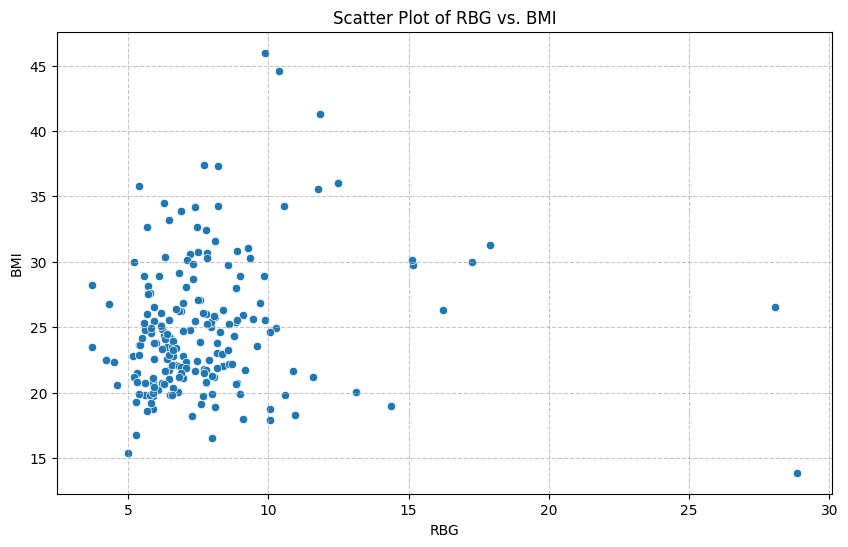


Interpretation: There is no statistically significant linear relationship between RBG and BMI (p >= 0.05).


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Extract the two variables
rbg = data['RBG']
bmi = data['BMI']

# Calculate Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(rbg, bmi)

print(f"Pearson Correlation Coefficient between RBG and BMI: {correlation_coefficient:.4f}")
print(f"P-value: {p_value:.4f}")

# Visualize the relationship with a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=rbg, y=bmi)
plt.title('Scatter Plot of RBG vs. BMI')
plt.xlabel('RBG')
plt.ylabel('BMI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nInterpretation: There is a statistically significant linear relationship between RBG and BMI (p < {alpha}).")
    if correlation_coefficient > 0:
        print("The relationship is positive, meaning as RBG increases, BMI tends to increase.")
    elif correlation_coefficient < 0:
        print("The relationship is negative, meaning as RBG increases, BMI tends to decrease.")
    else:
        print("The correlation coefficient is close to zero, but still statistically significant.")
else:
    print(f"\nInterpretation: There is no statistically significant linear relationship between RBG and BMI (p >= {alpha}).")

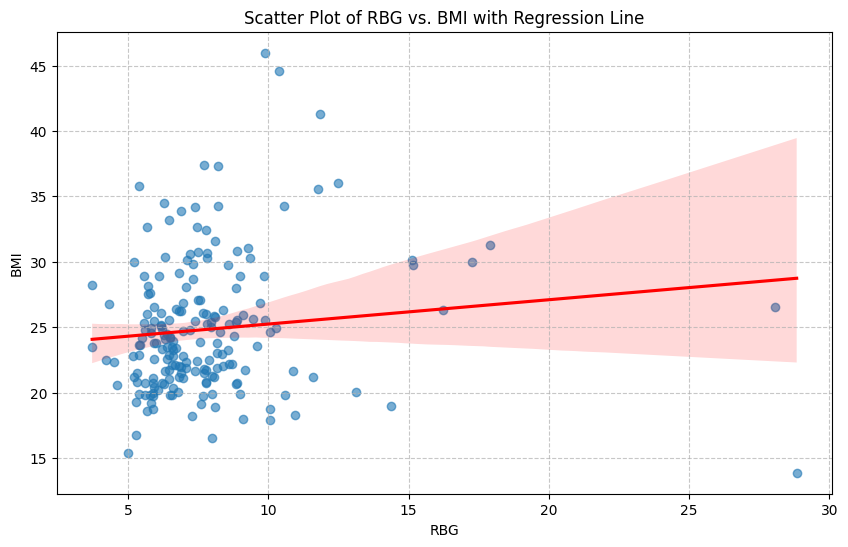

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the relationship with a scatter plot and a linear regression line
plt.figure(figsize=(10, 6))
sns.regplot(x=rbg, y=bmi, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Scatter Plot of RBG vs. BMI with Regression Line')
plt.xlabel('RBG')
plt.ylabel('BMI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 1. Automatically grab all categorical columns
cat_cols = data.select_dtypes(include=['object', 'category']).columns
# 2. Loop through them and print counts and percentages
for col in cat_cols:
    print(f"--- {col} ---")

    # Calculate counts
    counts = data[col].value_counts()

    # Calculate percentages (normalize=True)
    percents = data[col].value_counts(normalize=True) * 100

    # Combine them into a small table for readability
    df_summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percents})
    print(df_summary)
    print("\n") # Adds a space between columns

--- Gender ---
        Count  Percentage (%)
Gender                       
Female    141       73.056995
Male       52       26.943005


--- Age ---
              Count  Percentage (%)
Age                                
60 and above     69       35.751295
50-59            42       21.761658
40-49            42       21.761658
18-29            21       10.880829
30-39            19        9.844560


--- HLFE ---
                 Count  Percentage (%)
HLFE                                  
None or primary     87       45.077720
Secondary           77       39.896373
Tertiary            29       15.025907


--- Religion ---
                Count  Percentage (%)
Religion                             
Christianity      174       90.155440
Islam              17        8.808290
Traditionalist      2        1.036269


--- Occupa ---
                            Count  Percentage (%)
Occupa                                           
Trader                         40       20.833333
Trader       

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

# 1. Define your target variable and a list of factors you want to test
target = 'rbg_2l'
factors = ['Gender','HLFE', 'occupation', 'Family_type', 'Family_history_of_DMLR', 'Age', 'Physical_activity',  'add_salts_to_cooked_food', 'alcohol', 'bmi_2l', 'htn_2l', 'smoke_tobacco'] # Add all your column names here

# 2. Loop through each factor
for factor in factors:
    print(f"\n" + "="*30)
    print(f"ANALYSIS: {factor} vs {target}")
    print("="*30)

    # Create the frequency table (Counts)
    ct_counts = pd.crosstab(data[factor], data[target])

    # Create the percentage table (Row-wise percentages)
    ct_percent = pd.crosstab(data[factor], data[target], normalize='index') * 100

    # Perform the Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(ct_counts)

    # Display Results
    print("\n--- Frequency Count Table (Counts) ---")
    print(ct_counts)
    print("--- Percentage Table (Row %) ---")
    print(ct_percent.round(2))

    print("\n--- Chi-Square Test Results ---")
    print(f"Chi-Square Statistic: {chi2:.4f}")
    print(f"P-value: {p:.4f}")
    print(f"Degrees of Freedom: {dof}")

    # Quick Interpretation
    alpha = 0.05
    if p < alpha:
        print("\nResult: Statistically significant (Reject H0)")
    else:
        print("\nResult: Not statistically significant (Fail to reject H0)")


ANALYSIS: Gender vs rbg_2l

--- Frequency Count Table (Counts) ---
rbg_2l  diabetes  normal
Gender                  
Female        10     131
Male           3      49
--- Percentage Table (Row %) ---
rbg_2l  diabetes  normal
Gender                  
Female      7.09   92.91
Male        5.77   94.23

--- Chi-Square Test Results ---
Chi-Square Statistic: 0.0000
P-value: 0.9987
Degrees of Freedom: 1

Result: Not statistically significant (Fail to reject H0)

ANALYSIS: HLFE vs rbg_2l

--- Frequency Count Table (Counts) ---
rbg_2l           diabetes  normal
HLFE                             
None or primary         8      79
Secondary               4      73
Tertiary                1      28
--- Percentage Table (Row %) ---
rbg_2l           diabetes  normal
HLFE                             
None or primary      9.20   90.80
Secondary            5.19   94.81
Tertiary             3.45   96.55

--- Chi-Square Test Results ---
Chi-Square Statistic: 1.6278
P-value: 0.4431
Degrees of Freedom: 2



In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

# 1. Define your target variable and a list of factors you want to test
target = 'htn_2l'
factors = ['rbg_2l','Gender','HLFE', 'occupation', 'Family_type', 'Family_history_of_htn', 'Age', 'Physical_activity',  'add_salts_to_cooked_food', 'alcohol', 'bmi_2l', 'smoke_tobacco'] # Add all your column names here

# 2. Loop through each factor
for factor in factors:
    print(f"\n" + "="*30)
    print(f"ANALYSIS: {factor} vs {target}")
    print("="*30)

    # Create the frequency table (Counts)
    ct_counts = pd.crosstab(data[factor], data[target])

    # Create the percentage table (Row-wise percentages)
    ct_percent = pd.crosstab(data[factor], data[target], normalize='index') * 100

    # Perform the Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(ct_counts)

    # Display Results
    print("\n--- Frequency Count Table (Counts) ---")
    print(ct_counts)
    print("--- Percentage Table (Row %) ---")
    print(ct_percent.round(2))

    print("\n--- Chi-Square Test Results ---")
    print(f"Chi-Square Statistic: {chi2:.4f}")
    print(f"P-value: {p:.4f}")
    print(f"Degrees of Freedom: {dof}")

    # Quick Interpretation
    alpha = 0.05
    if p < alpha:
        print("\nResult: Statistically significant (Reject H0)")
    else:
        print("\nResult: Not statistically significant (Fail to reject H0)")


ANALYSIS: rbg_2l vs htn_2l

--- Frequency Count Table (Counts) ---
htn_2l    HTN  Normal
rbg_2l               
diabetes    4       9
normal     57     123
--- Percentage Table (Row %) ---
htn_2l      HTN  Normal
rbg_2l                 
diabetes  30.77   69.23
normal    31.67   68.33

--- Chi-Square Test Results ---
Chi-Square Statistic: 0.0000
P-value: 1.0000
Degrees of Freedom: 1

Result: Not statistically significant (Fail to reject H0)

ANALYSIS: Gender vs htn_2l

--- Frequency Count Table (Counts) ---
htn_2l  HTN  Normal
Gender             
Female   40     101
Male     21      31
--- Percentage Table (Row %) ---
htn_2l    HTN  Normal
Gender               
Female  28.37   71.63
Male    40.38   59.62

--- Chi-Square Test Results ---
Chi-Square Statistic: 2.0119
P-value: 0.1561
Degrees of Freedom: 1

Result: Not statistically significant (Fail to reject H0)

ANALYSIS: HLFE vs htn_2l

--- Frequency Count Table (Counts) ---
htn_2l           HTN  Normal
HLFE                        
None

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# 1. LOAD DATA
# Make sure the file name matches your edited Excel file
df = pd.read_excel("/content/drive/MyDrive/data_analysis/Mass_screening_agbado_april2026_analyze.xlsx")

# 2. PRE-PROCESSING
# Merge younger groups to ensure we have 'events' in the reference category
df['Age_Fixed'] = df['Age'].replace({'18-29': '18-39', '30-39': '18-39'})

# Ensure target is float (1 = High SBP, 0 = Normal)
y = df['rbg_2llr'].astype(float)

# Define all independent variables for the Adjusted model
covariates = [
    'BMI', 'GenderLR', 'htn_2llr', 'Family_history_of_DMLR',
     'tobaccoLR', 'alcoholLR', 'Age_Fixed'
]

# 3. ANALYSIS FUNCTION
def run_logit(cols):
    # drop_first=True makes the first alphabetical category the reference group
    X = pd.get_dummies(df[cols], drop_first=True, dtype=int)
    X = sm.add_constant(X)
    # Increase maxiter and try 'lbfgs' method for better convergence
    return sm.Logit(y, X).fit(method='lbfgs', maxiter=1000, disp=False)

# 4. BUILD RESULTS TABLE
final_results = []

# Get Adjusted stats (all variables)
adj_model = run_logit(covariates)
a_ors, a_cis, a_ps = np.exp(adj_model.params), np.exp(adj_model.conf_int()), adj_model.pvalues

# Get Crude stats (one variable at a time)
for var in covariates:
    c_model = run_logit([var])
    c_ors, c_cis, c_ps = np.exp(c_model.params), np.exp(c_model.conf_int()), c_model.pvalues

    for i in range(1, len(c_ors)): # Skip constant
        v_name = c_ors.index[i]

        final_results.append({
            'Variable': v_name,
            'Crude OR (95% CI)': f"{c_ors.iloc[i]:.2f} ({c_cis.iloc[i,0]:.2f}-{c_cis.iloc[i,1]:.2f})",
            'p-value (Crude)': f"{c_ps.iloc[i]:.3f}",
            'Adjusted OR (95% CI)': f"{a_ors[v_name]:.2f} ({a_cis.loc[v_name,0]:.2f}-{a_cis.loc[v_name,1]:.2f})",
            'p-value (Adjusted)': f"{a_ps[v_name]:.3f}"
        })

# 5. DISPLAY
output_table = pd.DataFrame(final_results)
print("\n--- FINAL PUBLICATION TABLE ---")
print(output_table.to_string(index=False))

# Optional: Save to Excel for easy copy-pasting into Word
# output_table.to_excel('Regression_Results.xlsx', index=False)


--- FINAL PUBLICATION TABLE ---
              Variable Crude OR (95% CI) p-value (Crude) Adjusted OR (95% CI) p-value (Adjusted)
                   BMI  1.10 (1.01-1.21)           0.037     1.10 (0.99-1.23)              0.086
              GenderLR  0.80 (0.21-3.04)           0.745     1.25 (0.20-7.97)              0.811
              htn_2llr  0.96 (0.28-3.25)           0.946     0.70 (0.17-2.81)              0.614
Family_history_of_DMLR 6.83 (1.81-25.72)           0.005    7.04 (1.62-30.58)              0.009
             tobaccoLR  0.92 (0.11-7.54)           0.936    1.85 (0.16-20.68)              0.619
             alcoholLR  1.05 (0.28-4.00)           0.943     0.74 (0.13-4.18)              0.734
       Age_Fixed_40-49 2.00 (0.35-11.59)           0.439    1.96 (0.30-12.95)              0.485
       Age_Fixed_50-59  1.46 (0.23-9.25)           0.686    1.85 (0.25-13.51)              0.545
Age_Fixed_60 and above  1.17 (0.20-6.70)           0.860    2.19 (0.31-15.55)              0.4

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# 1. LOAD DATA
# Make sure the file name matches your edited Excel file
df = pd.read_excel("/content/drive/MyDrive/data_analysis/Mass_screening_agbado_april2026_analyze.xlsx")

# 2. PRE-PROCESSING
# Merge younger groups to ensure we have 'events' in the reference category
df['Age_Fixed'] = df['Age'].replace({'18-29': '18-39', '30-39': '18-39'})

# Ensure target is float (1 = High SBP, 0 = Normal)
y = df['htn_2llr'].astype(float)

# Define all independent variables for the Adjusted model
covariates = [
    'BMI', 'GenderLR', 'rbg_2llr', 'RBG', 'famly_hx_of_htnLR', 'dietary_saltLR', 'Family_history_of_DMLR',
     'tobaccoLR', 'alcoholLR', 'Age_Fixed'
]

# 3. ANALYSIS FUNCTION
def run_logit(cols):
    # drop_first=True makes the first alphabetical category the reference group
    X = pd.get_dummies(df[cols], drop_first=True, dtype=int)
    X = sm.add_constant(X)
    # Increase maxiter and try 'lbfgs' method for better convergence
    return sm.Logit(y, X).fit(method='lbfgs', maxiter=1000, disp=False)

# 4. BUILD RESULTS TABLE
final_results = []

# Get Adjusted stats (all variables)
adj_model = run_logit(covariates)
a_ors, a_cis, a_ps = np.exp(adj_model.params), np.exp(adj_model.conf_int()), adj_model.pvalues

# Get Crude stats (one variable at a time)
for var in covariates:
    c_model = run_logit([var])
    c_ors, c_cis, c_ps = np.exp(c_model.params), np.exp(c_model.conf_int()), c_model.pvalues

    for i in range(1, len(c_ors)): # Skip constant
        v_name = c_ors.index[i]

        final_results.append({
            'Variable': v_name,
            'Crude OR (95% CI)': f"{c_ors.iloc[i]:.2f} ({c_cis.iloc[i,0]:.2f}-{c_cis.iloc[i,1]:.2f})",
            'p-value (Crude)': f"{c_ps.iloc[i]:.3f}",
            'Adjusted OR (95% CI)': f"{a_ors[v_name]:.2f} ({a_cis.loc[v_name,0]:.2f}-{a_cis.loc[v_name,1]:.2f})",
            'p-value (Adjusted)': f"{a_ps[v_name]:.3f}"
        })

# 5. DISPLAY
output_table = pd.DataFrame(final_results)
print("\n--- FINAL PUBLICATION TABLE ---")
print(output_table.to_string(index=False))

# Optional: Save to Excel for easy copy-pasting into Word
# output_table.to_excel('Regression_Results.xlsx', index=False)


--- FINAL PUBLICATION TABLE ---
              Variable Crude OR (95% CI) p-value (Crude) Adjusted OR (95% CI) p-value (Adjusted)
                   BMI  1.04 (0.98-1.11)           0.151     1.09 (1.01-1.17)              0.026
              GenderLR  1.71 (0.88-3.32)           0.113     1.48 (0.51-4.34)              0.473
              rbg_2llr  0.96 (0.28-3.25)           0.946     0.41 (0.05-3.27)              0.403
                   RBG  0.99 (0.90-1.10)           0.862     1.05 (0.86-1.28)              0.641
     famly_hx_of_htnLR  1.88 (0.55-6.40)           0.315     1.40 (0.31-6.34)              0.663
        dietary_saltLR  1.16 (0.61-2.23)           0.650     0.91 (0.43-1.93)              0.806
Family_history_of_DMLR  1.09 (0.36-3.34)           0.881     1.37 (0.33-5.66)              0.663
             tobaccoLR  0.98 (0.33-2.96)           0.975     0.50 (0.12-2.04)              0.333
             alcoholLR  2.04 (1.01-4.10)           0.046     2.24 (0.73-6.92)              0.1

In [ ]:
# Install python-docx to create Word documents
!pip install python-docx

Now I will generate the code to create the Word document and add the various analysis outputs. This process will involve capturing printed output and saving plots as images before embedding them.

In [ ]:
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from datetime import date
import io
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Create a new Word document
document = Document()

# --- Title Page ---
document.add_heading('', level=0) # Clear default heading if any
title = document.add_paragraph()
title.alignment = WD_ALIGN_PARAGRAPH.CENTER
title_run = title.add_run('Analysis Report: Mass Screening Data')
title_run.font.size = Pt(24)
title_run.bold = True

document.add_paragraph().add_run().add_break() # Spacer

author = document.add_paragraph()
author.alignment = WD_ALIGN_PARAGRAPH.CENTER
author_run = author.add_run('Generated by Colab Agent')
author_run.font.size = Pt(14)

current_date = document.add_paragraph()
current_date.alignment = WD_ALIGN_PARAGRAPH.CENTER
current_date_run = current_date.add_run(f"Date: {date.today().strftime('%Y-%m-%d')}")
current_date_run.font.size = Pt(12)

document.add_page_break() # Start new section on a new page

# Helper function to add a pandas DataFrame as a table to the document
def add_dataframe_to_document(doc, df, heading_text, caption_text, level=1):
    if heading_text: # Only add heading if provided
        doc.add_heading(heading_text, level=level)

    # Add caption before the table
    if caption_text:
        caption = doc.add_paragraph(f"Table: {caption_text}")
        # Caption style is not standard, defining alignment manually
        caption.alignment = WD_ALIGN_PARAGRAPH.CENTER
        caption.runs[0].font.size = Pt(10) # Smaller font for captions

    table = doc.add_table(rows=1, cols=len(df.columns))
    table.style = 'Table Grid' # Apply a grid style for better readability

    # Add header row (bold and centered)
    hdr_cells = table.rows[0].cells
    for i, col_name in enumerate(df.columns):
        cell_paragraph = hdr_cells[i].paragraphs[0]
        cell_run = cell_paragraph.add_run(str(col_name))
        cell_run.bold = True
        cell_paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER # Center header text

    # Add data rows (centered)
    for index, row in df.iterrows():
        row_cells = table.add_row().cells
        for i, cell_value in enumerate(row):
            cell_paragraph = row_cells[i].paragraphs[0]
            cell_run = cell_paragraph.add_run(str(cell_value))
            cell_paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER # Center cell text

    doc.add_paragraph() # Add a small space after the table

# Pre-processing for Age_Fixed column (needed for logistic regression)
data['Age_Fixed'] = data['Age'].replace({'18-29': '18-39', '30-39': '18-39'})

# --- 1. Data Overview ---
document.add_heading('1. Data Overview', level=1)
document.add_paragraph('This section provides a preliminary overview of the dataset, including its structure, descriptive statistics, and data types.')

# Add data.head() as a table
add_dataframe_to_document(document, data.head(), '1.1. First 5 Rows of the Dataset', 'First 5 rows of the dataset.', level=2)

# Add data.describe() as a table
add_dataframe_to_document(document, data.describe(), '1.2. Descriptive Statistics of Numerical Columns', 'Descriptive statistics for numerical columns.', level=2)

# Capture data.info() output (it prints directly, so we need to redirect stdout)
f = io.StringIO()
data.info(buf=f)
document.add_heading('1.3. Data Information (Column Types and Non-Null Counts)', level=2)
document.add_paragraph(f.getvalue())
f.close()
document.add_page_break()


# --- 2. Categorical Variable Summaries ---
document.add_heading('2. Categorical Variable Summaries', level=1)
document.add_paragraph('This section presents frequency counts and percentages for all categorical variables in the dataset.')

# Re-run the categorical analysis to capture outputs
cat_cols = data.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    heading = f'2.{col}: Counts and Percentages'
    caption = f'Frequency and percentage distribution for {col}.'
    counts = data[col].value_counts()
    percents = data[col].value_counts(normalize=True) * 100
    df_summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percents.round(2)}) # Round percentages
    add_dataframe_to_document(document, df_summary, heading, caption, level=2)
document.add_page_break()


# --- 3. Chi-Square Test Results ---
document.add_heading('3. Chi-Square Test Results', level=1)
document.add_paragraph('This section details the results of Chi-Square tests of independence between key factors and the target variables (RBG and HTN).')

# Capture RBG chi-square tests
document.add_heading('3.1. Chi-Square Tests for RBG', level=2)
target_rbg = 'rbg_2l'
factors_rbg = ['Gender','HLFE', 'occupation', 'Family_type', 'Family_history_of_DMLR', 'Age', 'Physical_activity',  'add_salts_to_cooked_food', 'alcohol', 'bmi_2l', 'htn_2l', 'smoke_tobacco']

for i, factor in enumerate(factors_rbg): # Use enumerate for figure numbering
    document.add_heading(f'3.1.{i+1}. {factor} vs {target_rbg}', level=3) # Add numbering
    ct_counts = pd.crosstab(data[factor], data[target_rbg])
    ct_percent = pd.crosstab(data[factor], data[target_rbg], normalize='index') * 100
    chi2, p, dof, expected = chi2_contingency(ct_counts)

    document.add_paragraph('Frequency Count Table (Counts):')
    add_dataframe_to_document(document, ct_counts, '', f'Count table for {factor} vs {target_rbg}.', level=4)
    document.add_paragraph('Percentage Table (Row %):')
    add_dataframe_to_document(document, ct_percent.round(2), '', f'Row percentages for {factor} vs {target_rbg}.', level=4)
    document.add_paragraph(f"Chi-Square Statistic: {chi2:.4f}")
    document.add_paragraph(f"P-value: {p:.4f}")
    document.add_paragraph(f"Degrees of Freedom: {dof}")
    if p < 0.05:
        document.add_paragraph("Result: Statistically significant (Reject H0)")
    else:
        document.add_paragraph("Result: Not statistically significant (Fail to reject H0)")
    document.add_paragraph() # Spacer

document.add_page_break()

# Capture HTN chi-square tests
document.add_heading('3.2. Chi-Square Tests for HTN', level=2)
target_htn = 'htn_2l'
factors_htn = ['rbg_2l','Gender','HLFE', 'occupation', 'Family_type', 'Family_history_of_htn', 'Age', 'Physical_activity',  'add_salts_to_cooked_food', 'alcohol', 'bmi_2l', 'smoke_tobacco']

for i, factor in enumerate(factors_htn):
    document.add_heading(f'3.2.{i+1}. {factor} vs {target_htn}', level=3)
    ct_counts = pd.crosstab(data[factor], data[target_htn])
    ct_percent = pd.crosstab(data[factor], data[target_htn], normalize='index') * 100
    chi2, p, dof, expected = chi2_contingency(ct_counts)

    document.add_paragraph('Frequency Count Table (Counts):')
    add_dataframe_to_document(document, ct_counts, '', f'Count table for {factor} vs {target_htn}.', level=4)
    document.add_paragraph('Percentage Table (Row %):')
    add_dataframe_to_document(document, ct_percent.round(2), '', f'Row percentages for {factor} vs {target_htn}.', level=4)
    document.add_paragraph(f"Chi-Square Statistic: {chi2:.4f}")
    document.add_paragraph(f"P-value: {p:.4f}")
    document.add_paragraph(f"Degrees of Freedom: {dof}")
    if p < 0.05:
        document.add_paragraph("Result: Statistically significant (Reject H0)")
    else:
        document.add_paragraph("Result: Not statistically significant (Fail to reject H0)")
    document.add_paragraph() # Spacer

document.add_page_break()


# --- 4. Linear Correlation (RBG vs BMI) ---
document.add_heading('4. Linear Correlation: RBG vs BMI', level=1)
document.add_paragraph('This section explores the linear relationship between Random Blood Glucose (RBG) and Body Mass Index (BMI).')

document.add_paragraph(f"Pearson Correlation Coefficient between RBG and BMI: {correlation_coefficient:.4f}")
document.add_paragraph(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    document.add_paragraph("Interpretation: There is a statistically significant linear relationship between RBG and BMI.")
    if correlation_coefficient > 0:
        document.add_paragraph("The relationship is positive, meaning as RBG increases, BMI tends to increase.")
    elif correlation_coefficient < 0:
        document.add_paragraph("The relationship is negative, meaning as RBG increases, BMI tends to decrease.")
else:
    document.add_paragraph("Interpretation: There is no statistically significant linear relationship between RBG and BMI.")

# Save the scatter plot with regression line as an image and add to document
plt.figure(figsize=(10, 6))
sns.regplot(x=rbg, y=bmi, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Scatter Plot of RBG vs. BMI with Regression Line')
plt.xlabel('RBG')
plt.ylabel('BMI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plot_path = '/content/rbg_bmi_regression_plot.png'
plt.savefig(plot_path)
plt.close() # Close the plot to prevent it from displaying in the notebook output

document.add_picture(plot_path, width=Inches(6))
# The picture is added as an InlineShape within a new paragraph. We need to get this paragraph to set its alignment.
last_paragraph_for_picture = document.paragraphs[-1]
last_paragraph_for_picture.alignment = WD_ALIGN_PARAGRAPH.CENTER

caption_paragraph = document.add_paragraph('Figure 1: Scatter Plot of RBG vs. BMI with Linear Regression Line and 95% Confidence Interval.')
caption_paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
caption_paragraph.runs[0].font.size = Pt(10) # Smaller font for captions
document.add_page_break()


# --- 5. Logistic Regression Results ---
document.add_heading('5. Logistic Regression Results', level=1)
document.add_paragraph('This section presents the crude and adjusted Odds Ratios (OR) from logistic regression models for RBG (rbg_2llr) and HTN (htn_2llr).')

# RBG_2llr Logistic Regression
document.add_heading('5.1. Logistic Regression for RBG (rbg_2llr)', level=2)
y_rbg = data['rbg_2llr'].astype(float)
rbg_covariates = [
    'BMI', 'GenderLR', 'htn_2llr', 'Family_history_of_DMLR',
     'tobaccoLR', 'alcoholLR', 'Age_Fixed'
]
# Re-run the model for RBG to get the output_table
def run_logit_rbg(cols):
    X = pd.get_dummies(data[cols], drop_first=True, dtype=int)
    X = sm.add_constant(X)
    return sm.Logit(y_rbg, X).fit(method='lbfgs', maxiter=1000, disp=False)

rbg_adj_model = run_logit_rbg(rbg_covariates)
rbg_a_ors, rbg_a_cis, rbg_a_ps = np.exp(rbg_adj_model.params), np.exp(rbg_adj_model.conf_int()), rbg_adj_model.pvalues

rbg_final_results = []
for var in rbg_covariates:
    c_model = run_logit_rbg([var])
    c_ors, c_cis, c_ps = np.exp(c_model.params), np.exp(c_model.conf_int()), c_model.pvalues

    for i in range(1, len(c_ors)): # Skip constant
        v_name = c_ors.index[i]
        rbg_final_results.append({
            'Variable': v_name,
            'Crude OR (95% CI)': f"{c_ors.iloc[i]:.2f} ({c_cis.iloc[i,0]:.2f}-{c_cis.iloc[i,1]:.2f})",
            'p-value (Crude)': f"{c_ps.iloc[i]:.3f}",
            'Adjusted OR (95% CI)': f"{rbg_a_ors[v_name]:.2f} ({rbg_a_cis.loc[v_name,0]:.2f}-{rbg_a_cis.loc[v_name,1]:.2f})",
            'p-value (Adjusted)': f"{rbg_a_ps[v_name]:.3f}"
        })
rbg_output_table = pd.DataFrame(rbg_final_results)
add_dataframe_to_document(document, rbg_output_table, '', 'Logistic Regression Results for RBG (rbg_2llr).', level=3) # Empty heading, use caption only

document.add_page_break()

# HTN_2llr Logistic Regression
document.add_heading('5.2. Logistic Regression for HTN (htn_2llr)', level=2)
y_htn = data['htn_2llr'].astype(float)
htn_covariates = [
    'BMI', 'GenderLR', 'rbg_2llr', 'famly_hx_of_htnLR', 'dietary_saltLR', 'Family_history_of_DMLR',
     'tobaccoLR', 'alcoholLR', 'Age_Fixed'
]
# Re-run the model for HTN to get the output_table
def run_logit_htn(cols):
    X = pd.get_dummies(data[cols], drop_first=True, dtype=int)
    X = sm.add_constant(X)
    return sm.Logit(y_htn, X).fit(method='lbfgs', maxiter=1000, disp=False)

htn_adj_model = run_logit_htn(htn_covariates)
htn_a_ors, htn_a_cis, htn_a_ps = np.exp(htn_adj_model.params), np.exp(htn_adj_model.conf_int()), htn_adj_model.pvalues

htn_final_results = []
for var in htn_covariates:
    c_model = run_logit_htn([var])
    c_ors, c_cis, c_ps = np.exp(c_model.params), np.exp(c_model.conf_int()), c_model.pvalues

    for i in range(1, len(c_ors)): # Skip constant
        v_name = c_ors.index[i]
        htn_final_results.append({
            'Variable': v_name,
            'Crude OR (95% CI)': f"{c_ors.iloc[i]:.2f} ({c_cis.iloc[i,0]:.2f}-{c_cis.iloc[i,1]:.2f})",
            'p-value (Crude)': f"{c_ps.iloc[i]:.3f}",
            'Adjusted OR (95% CI)': f"{htn_a_ors[v_name]:.2f} ({htn_a_cis.loc[v_name,0]:.2f}-{htn_a_cis.loc[v_name,1]:.2f})",
            'p-value (Adjusted)': f"{htn_a_ps[v_name]:.3f}"
        })
htn_output_table = pd.DataFrame(htn_final_results)
add_dataframe_to_document(document, htn_output_table, '', 'Logistic Regression Results for HTN (htn_2llr).', level=3) # Empty heading, use caption only

document.add_page_break()


# Save the document
document_path = '/content/analysis_report.docx'
document.save(document_path)
print(f"\nAnalysis report saved to {document_path}")